In [2]:
import pandas as pd
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot

In [3]:
df =pd.read_csv('/content/AirPassengers.csv')

In [4]:
df.head(5)

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [8]:
df.rename(columns={'Month':'ds','#Passengers':'y'},inplace=True)

In [9]:
df.head(5)

,ds,y
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ds      144 non-null    object
 1   y       144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [12]:
df['ds'] = pd.to_datetime(df['ds'])

In [13]:
#Fitting the Prophet Model
model = Prophet()
model.fit(df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [14]:
#Making Future preditions for 5 years

future = model.make_future_dataframe(periods=12*5,freq='M')

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [15]:
#Forecasting
forecast = model.predict(future)

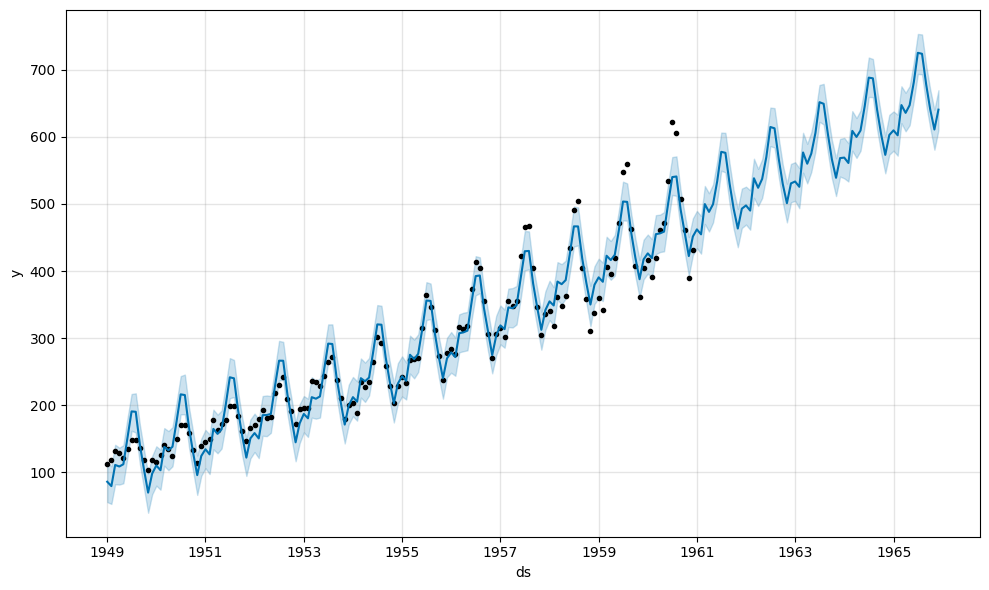

In [16]:
# Plotting the forecasted data

fig1 = model.plot(forecast)

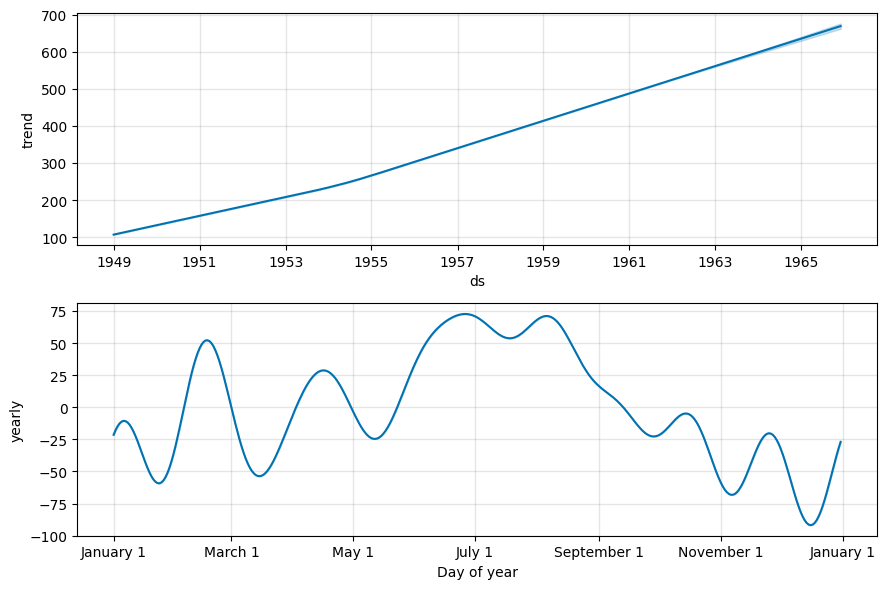

In [17]:
#Plot components

fig2 = model.plot_components(forecast)